In [1]:
#
# ⚡ UNIVERSAL FIRST CELL - Run this FIRST in every notebook!
# Compatible with: Google Colab, GitHub Codespaces, Local
#

import os
import subprocess
import sys

# Detect environment
IS_COLAB = "google.colab" in sys.modules
IS_CODESPACES = os.path.exists("/.devcontainer") or os.path.exists("/workspaces")
IS_LOCAL = not (IS_COLAB or IS_CODESPACES)

print(f"🚀 Environment: {'Colab' if IS_COLAB else 'Codespaces' if IS_CODESPACES else 'Local'}")

# Ensure we are in the root directory for relative paths
while not os.path.exists('data') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
print(f"📁 Working directory set to: {os.getcwd()}")

print("✅ Environment ready!")

🚀 Environment: Local
📁 Working directory set to: /home/aidas/repos/computer-data-analysis-report
✅ Environment ready!


# 15 - Exploratory Data Analysis

**Goal**: Descriptive analysis of 5,295 real data center buildout events extracted from GDELT news.

**Data**: `data/processed/buildout_promises_real.csv`

**Sections**: Setup | Descriptive Stats | Target Distribution | Event Timing | MW Capacity | Location | Feature Correlation | Data Quality | Synthetic vs Real | LaTeX Output

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Output directory for figures
FIGS_DIR = 'reports/figures'
os.makedirs(FIGS_DIR, exist_ok=True)

# Plot style
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'figure.figsize': (10, 5)
})

print("✅ Libraries imported & configured")

✅ Libraries imported & configured


In [3]:
# Load data
df = pd.read_csv('data/processed/buildout_promises_real.csv')
print(f"📊 Dataset: {len(df)} rows × {len(df.columns)} columns")

# Parse date column (YYYYMMDDHHMMSS -> datetime)
df['announcement_date'] = pd.to_datetime(df['date'].astype(str), format='%Y%m%d%H%M%S', errors='coerce')
df['year'] = df['announcement_date'].dt.year.astype('Int64')

# Parse mw_capacity as numeric
df['mw_capacity'] = pd.to_numeric(df['mw_capacity'], errors='coerce')

# Parse promise_kept
df['promise_kept'] = pd.to_numeric(df['promise_kept'], errors='coerce')

# Add status label
df['status'] = 'Pending'
df.loc[df['promise_kept'] == 1, 'status'] = 'Kept'
df.loc[df['promise_kept'] == 0, 'status'] = 'Failed'

print(f"   Date range: {df['announcement_date'].min():%Y-%m-%d} to {df['announcement_date'].max():%Y-%m-%d}")
print(f"   Years: {sorted(df['year'].dropna().unique())}")
print(f"   Companies: {df['company'].nunique()}")
print(f"   States: {df['location_state'].nunique() - 1} (plus {df['location_state'].isna().sum()} NaN)")
print()
print(f"   Promise kept: {df['promise_kept'].sum():.0f} ({df['promise_kept'].mean()*100:.1f}% of labeled)")
print(f"   Promise failed: {(df['promise_kept'] == 0).sum():.0f}")
print(f"   Pending (unlabeled): {df['promise_kept'].isna().sum():.0f}")
print("✅ Data loaded")

📊 Dataset: 5295 rows × 16 columns
   Date range: 2020-01-02 to 2026-05-22
   Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
   Companies: 17
   States: 50 (plus 3049 NaN)

   Promise kept: 105 (82.7% of labeled)
   Promise failed: 22
   Pending (unlabeled): 5168
✅ Data loaded


## 1. Descriptive Statistics

📅 Events by Year:
year
2020     553
2021     472
2022     812
2023     890
2024    1478
2025     942
2026     148



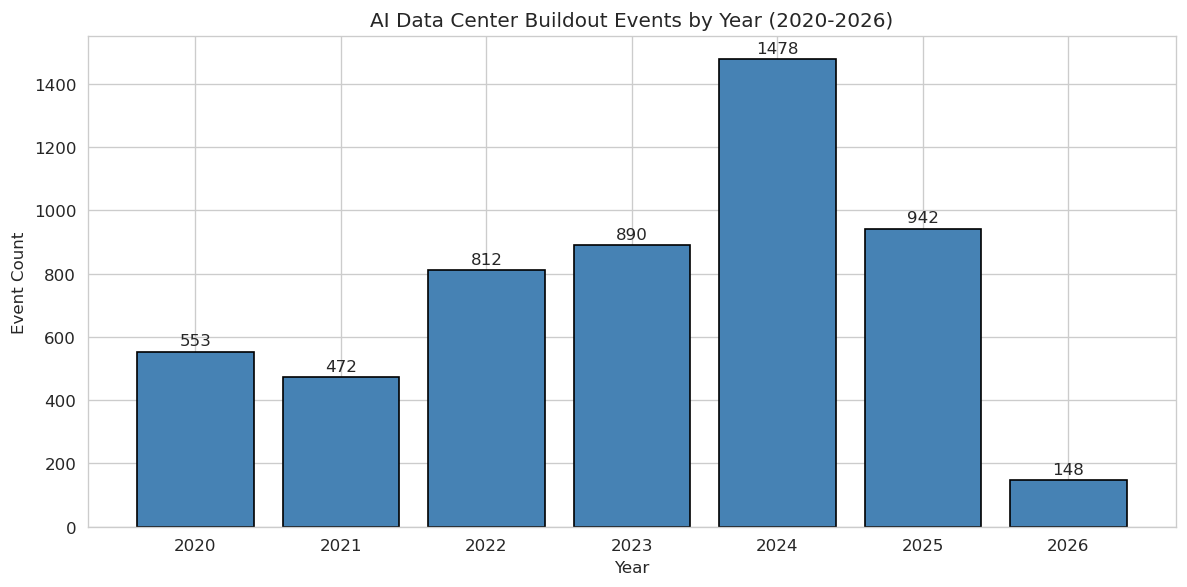

✅ Saved fig1_events_by_year.png


In [4]:
# Events by year
year_counts = df['year'].value_counts().sort_index()
print("📅 Events by Year:")
print(year_counts.to_string())
print()

fig1, ax1 = plt.subplots()
bars = ax1.bar(year_counts.index.astype(str), year_counts.values, color='steelblue', edgecolor='black')
ax1.bar_label(bars, padding=2)
ax1.set_xlabel('Year')
ax1.set_ylabel('Event Count')
ax1.set_title('AI Data Center Buildout Events by Year (2020-2026)')
fig1.tight_layout()
fig1.savefig(f'{FIGS_DIR}/fig1_events_by_year.png')
plt.show()
print(f"✅ Saved fig1_events_by_year.png")

🆔 Top 10 Companies by Event Count:
company
Microsoft              1650
Digital Realty          755
Amazon Web Services     712
Google                  698
NVIDIA                  625
Facebook                238
Microsoft Corp          216
Oracle                  124
Alphabet                 57
Amazon                   52



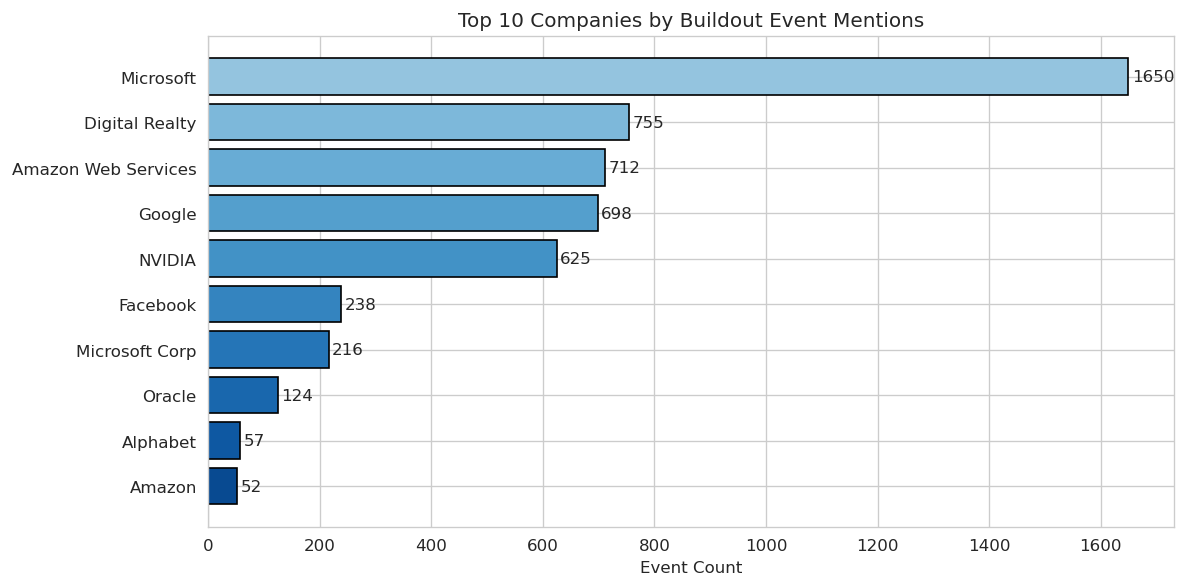

✅ Saved fig2_top_companies.png


In [5]:
# Top companies
top_n = 10
company_counts = df['company'].value_counts().head(top_n)

print(f"🆔 Top {top_n} Companies by Event Count:")
print(company_counts.to_string())
print()

fig2, ax2 = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]
bars = ax2.barh(company_counts.index[::-1], company_counts.values[::-1], color=colors, edgecolor='black')
ax2.bar_label(bars, padding=2)
ax2.set_xlabel('Event Count')
ax2.set_title(f'Top {top_n} Companies by Buildout Event Mentions')
fig2.tight_layout()
fig2.savefig(f'{FIGS_DIR}/fig2_top_companies.png')
plt.show()
print(f"✅ Saved fig2_top_companies.png")

In [6]:
# Summary statistics table
print("📊 Summary Statistics by Company (mw_capacity):")
print()

summary_stats = df.groupby('company')['mw_capacity'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
summary_stats = summary_stats.sort_values('count', ascending=False)
summary_stats['mean'] = summary_stats['mean'].round(1)
summary_stats['median'] = summary_stats['median'].round(1)
summary_stats['std'] = summary_stats['std'].round(1)
print(summary_stats.to_string())
print()

# Overall stats
print("Overall:")
print(f"  Total events: {len(df)}")
print(f"  Events with MW data: {df['mw_capacity'].notna().sum()} ({df['mw_capacity'].notna().mean()*100:.1f}%)")
print(f"  Mean MW: {df['mw_capacity'].mean():.0f}")
print(f"  Median MW: {df['mw_capacity'].median():.0f}")
print(f"  Std MW: {df['mw_capacity'].std():.0f}")
print(f"  Total MW (sum): {df['mw_capacity'].sum():,.0f}")

📊 Summary Statistics by Company (mw_capacity):

                     count     mean  median      std    min      max
company                                                             
Microsoft              515   1084.4   170.0   6797.9    1.0  80000.0
Digital Realty         432    462.8    83.0   3006.3    1.0  47000.0
Google                 207   1746.5   275.0   8125.7    1.0  76000.0
Amazon Web Services    155   3153.5   290.0  13334.2    1.0  90000.0
NVIDIA                  99    152.9    75.0    186.7    1.0    800.0
Facebook                74    221.0   180.0    214.7    1.0    885.0
Oracle                  39    138.0    48.0    209.7    1.0    800.0
Microsoft Corp          37   5865.8   488.7  18027.8    4.0  87000.0
Prologis                31    355.2   144.0    717.5    3.0   4000.0
Crusoe                  14    658.6   200.0   1310.4   10.0   5000.0
Meta                    10    284.7   150.1    293.1   10.0    850.0
Alphabet                 9   7450.6   500.0  10534.4  3

## 2. Target Distribution (Promise Keeping)

🏆 Promise Keeping Analysis
   Labeled events: 127
   Kept: 105 (82.7%)
   Failed: 22 (17.3%)
   Keep rate: 0.827

--- By Company ---
                     total_labeled  kept  keep_rate  failed
company                                                    
Microsoft                       42  34.0      0.810     8.0
Amazon Web Services             24  22.0      0.917     2.0
Digital Realty                  22  20.0      0.909     2.0
Google                          12   9.0      0.750     3.0
NVIDIA                           9   8.0      0.889     1.0
Facebook                         9   5.0      0.556     4.0
Oracle                           3   3.0      1.000     0.0
Equinix                          3   3.0      1.000     0.0
Alphabet                         2   1.0      0.500     1.0
Microsoft Corp                   1   0.0      0.000     1.0



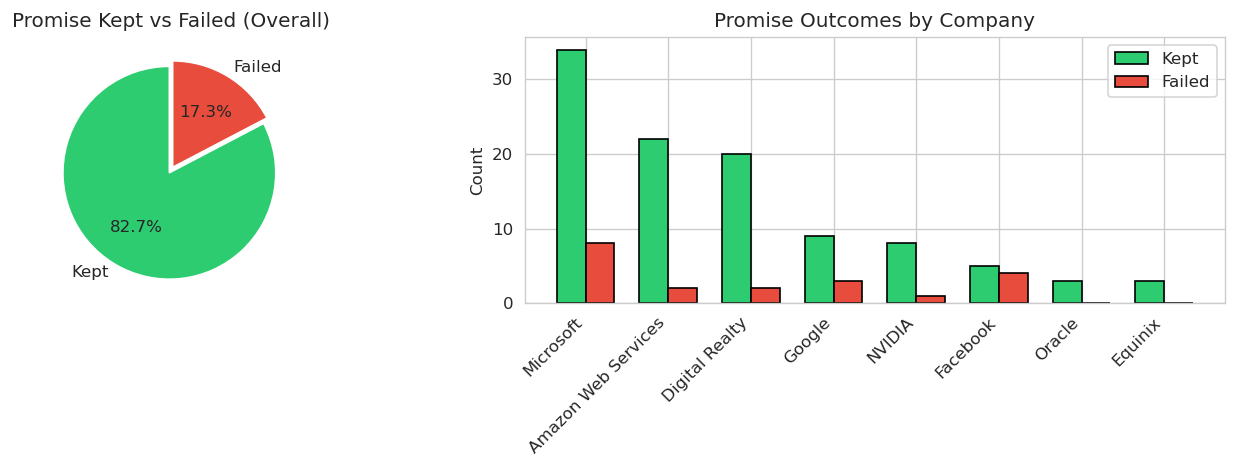

✅ Saved fig3_promise_ratio.png


In [7]:
# Overall promise_kept ratio
labeled = df[df['promise_kept'].notna()].copy()
print(f"🏆 Promise Keeping Analysis")
print(f"   Labeled events: {len(labeled)}")
print(f"   Kept: {labeled['promise_kept'].sum():.0f} ({labeled['promise_kept'].mean()*100:.1f}%)")
print(f"   Failed: {(labeled['promise_kept'] == 0).sum():.0f} ({(1-labeled['promise_kept'].mean())*100:.1f}%)")
print(f"   Keep rate: {labeled['promise_kept'].mean():.3f}")
print()

# By company
print("--- By Company ---")
company_keep = labeled.groupby('company')['promise_kept'].agg(['count', 'sum', 'mean'])
company_keep['mean'] = company_keep['mean'].round(3)
company_keep.columns = ['total_labeled', 'kept', 'keep_rate']
company_keep['failed'] = company_keep['total_labeled'] - company_keep['kept']
company_keep = company_keep.sort_values('total_labeled', ascending=False)
print(company_keep.to_string())
print()

fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(12, 4))

# Pie
ax3a.pie([labeled['promise_kept'].sum(), (labeled['promise_kept'] == 0).sum()],
        labels=['Kept', 'Failed'], autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.03, 0.03))
ax3a.set_title('Promise Kept vs Failed (Overall)')

# Bar by company
top_keep = company_keep.head(8)
x = np.arange(len(top_keep))
width = 0.35
ax3b.bar(x - width/2, top_keep['kept'], width, label='Kept', color='#2ecc71', edgecolor='black')
ax3b.bar(x + width/2, top_keep['failed'], width, label='Failed', color='#e74c3c', edgecolor='black')
ax3b.set_xticks(x)
ax3b.set_xticklabels(top_keep.index, rotation=45, ha='right')
ax3b.set_ylabel('Count')
ax3b.set_title('Promise Outcomes by Company')
ax3b.legend()

fig3.tight_layout()
fig3.savefig(f'{FIGS_DIR}/fig3_promise_ratio.png')
plt.show()
print(f"✅ Saved fig3_promise_ratio.png")

## 3. Event Timing Analysis

📅 Event Timing Analysis
   Earliest: 2020-01-02 17:30:00
   Latest: 2026-05-22 18:15:00
   Span: 2332 days

--- Target Completion Dates ---
   Rows with target: 1246 (23.5%)

Target year distribution:
target_year
2018.0      7
2019.0      6
2020.0     14
2021.0     24
2022.0     38
2023.0     75
2024.0     84
2025.0    163
2026.0    104
2027.0     86
2028.0     54
2029.0     28
2030.0    395
2031.0      9
2032.0     21
2033.0      3
2034.0      3
2035.0     19
2036.0      2
2037.0      7
2039.0      3
2040.0     36
2042.0      1
2044.0      1
2045.0      1
2050.0     29

--- Announcement-to-Target Lag ---
   Mean lag: 4.9 years
   Median lag: 4.0 years
   Range: -7 to 30 years



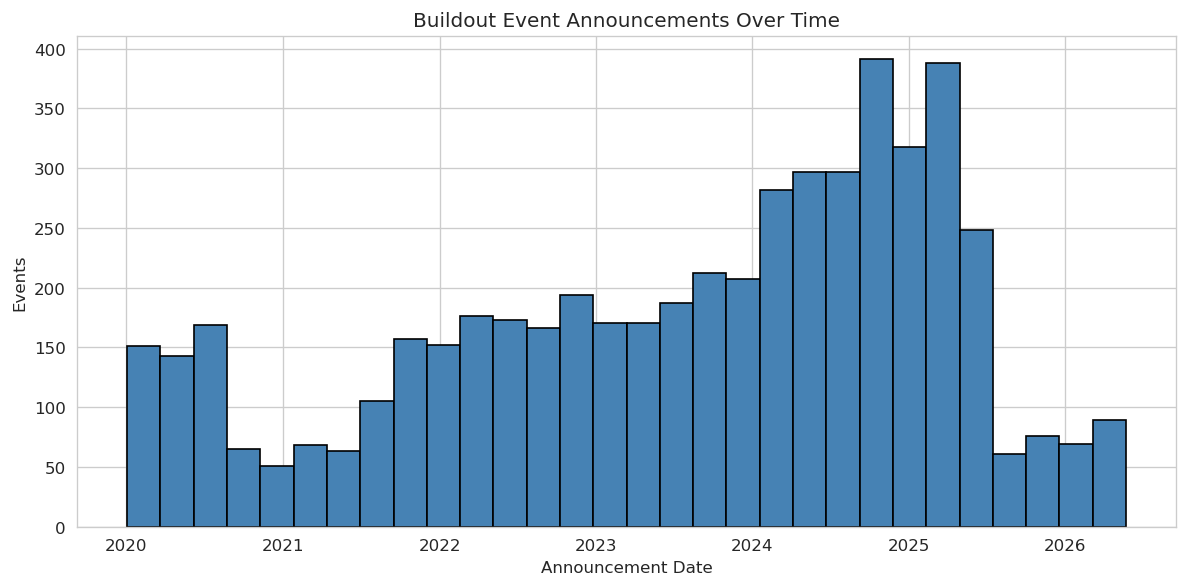

✅ Saved fig4_event_timeline.png


In [8]:
# Announcement date distribution
print("📅 Event Timing Analysis")
print(f"   Earliest: {df['announcement_date'].min()}")
print(f"   Latest: {df['announcement_date'].max()}")
print(f"   Span: {(df['announcement_date'].max() - df['announcement_date'].min()).days} days")
print()

# Target completion date analysis
tcd = df['target_completion_date'].dropna()
print(f"--- Target Completion Dates ---")
print(f"   Rows with target: {len(tcd)} ({len(tcd)/len(df)*100:.1f}%)")
print()

# Extract years from target_completion_date
def extract_target_year(s):
    if pd.isna(s):
        return None
    s = str(s).lower().strip()
    for yr in range(2018, 2051):
        if str(yr) in s:
            return yr
    return None

df['target_year'] = df['target_completion_date'].apply(extract_target_year)
target_year_counts = df['target_year'].value_counts().sort_index()
print("Target year distribution:")
print(target_year_counts.to_string())
print()

# Timeline: event date vs target year
df_timeline = df[df['target_year'].notna() & df['announcement_date'].notna()].copy()
df_timeline['announce_year'] = df_timeline['announcement_date'].dt.year
df_timeline['lag_years'] = df_timeline['target_year'] - df_timeline['announce_year']

print("--- Announcement-to-Target Lag ---")
print(f"   Mean lag: {df_timeline['lag_years'].mean():.1f} years")
print(f"   Median lag: {df_timeline['lag_years'].median():.1f} years")
print(f"   Range: {df_timeline['lag_years'].min():.0f} to {df_timeline['lag_years'].max():.0f} years")
print()

fig4, ax4 = plt.subplots()
ax4.hist(df['announcement_date'].dt.to_pydatetime(), bins=30, color='steelblue', edgecolor='black')
ax4.set_xlabel('Announcement Date')
ax4.set_ylabel('Events')
ax4.set_title('Buildout Event Announcements Over Time')
fig4.tight_layout()
fig4.savefig(f'{FIGS_DIR}/fig4_event_timeline.png')
plt.show()
print(f"✅ Saved fig4_event_timeline.png")

## 4. MW Capacity Analysis

⚡ MW Capacity Analysis
   Non-null MW: 1638 (30.9%)
   Mean: 1235 MW
   Median: 150 MW
   Std: 7302 MW
   Min: 1 MW
   Max: 90000 MW
   Total: 2,022,661 MW

--- MW by Confidence Tier ---
             count    mean      std  min   25%    50%    75%      max
confidence                                                           
high        1349.0   861.6   5461.8  1.0  32.0  150.0  480.0  90000.0
low            0.0     NaN      NaN  NaN   NaN    NaN    NaN      NaN
medium       289.0  2976.8  12639.0  1.0  20.0  150.0  500.0  87000.0

--- MW by Company (top 10 by count) ---
                     count    mean       sum
company                                     
Microsoft              515  1084.4  558457.7
Amazon Web Services    155  3153.5  488799.0
Google                 207  1746.5  361531.4
Microsoft Corp          37  5865.8  217035.7
Digital Realty         432   462.8  199912.3
Alphabet                 9  7450.6   67055.0
Facebook                74   221.0   16354.4
NVIDIA           

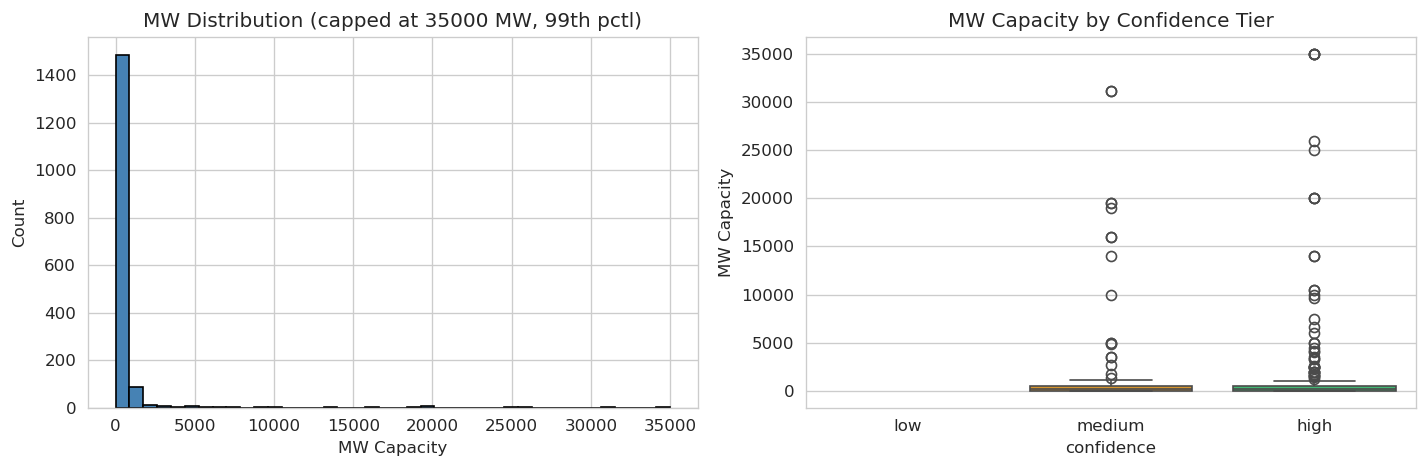

✅ Saved fig5_mw_analysis.png


In [9]:
print("⚡ MW Capacity Analysis")
mws = df['mw_capacity'].dropna()
print(f"   Non-null MW: {len(mws)} ({len(mws)/len(df)*100:.1f}%)")
print(f"   Mean: {mws.mean():.0f} MW")
print(f"   Median: {mws.median():.0f} MW")
print(f"   Std: {mws.std():.0f} MW")
print(f"   Min: {mws.min():.0f} MW")
print(f"   Max: {mws.max():.0f} MW")
print(f"   Total: {mws.sum():,.0f} MW")
print()

# MW by confidence tier
print("--- MW by Confidence Tier ---")
mw_conf = df.groupby('confidence')['mw_capacity'].describe()
print(mw_conf.round(1).to_string())
print()

# MW top companies
print("--- MW by Company (top 10 by count) ---")
mw_company = df.groupby('company')['mw_capacity'].agg(['count', 'mean', 'sum'])
mw_company = mw_company[mw_company['count'] >= 5].sort_values('sum', ascending=False)
mw_company = mw_company.round(1)
print(mw_company.to_string())
print()

fig5, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram (cap at 99th percentile)
cap = mws.quantile(0.99)
mws_capped = mws[mws <= cap]
axes[0].hist(mws_capped, bins=40, color='steelblue', edgecolor='black')
axes[0].set_xlabel('MW Capacity')
axes[0].set_ylabel('Count')
axes[0].set_title(f'MW Distribution (capped at {cap:.0f} MW, 99th pctl)')

# Box plot by confidence
df_box = df[df['mw_capacity'].notna() & df['confidence'].notna()].copy()
sns.boxplot(data=df_box[df_box['mw_capacity'] <= cap],
            x='confidence', y='mw_capacity', order=['low', 'medium', 'high'], ax=axes[1],
            palette=['#e74c3c', '#f39c12', '#2ecc71'])
axes[1].set_title('MW Capacity by Confidence Tier')
axes[1].set_ylabel('MW Capacity')

fig5.tight_layout()
fig5.savefig(f'{FIGS_DIR}/fig5_mw_analysis.png')
plt.show()
print(f"✅ Saved fig5_mw_analysis.png")

## 5. Location Analysis

📍 Location Analysis
--- Top 15 States by Event Count ---
location_state
TX    309
VA    290
CA    213
DC    175
NY    138
AZ     86
OH     81
IL     79
PA     67
GA     63
IA     61
MA     46
OR     46
WI     39
NV     36

   States with events: 50 (excluding NaN)
   Missing location: 3049 (57.6%)




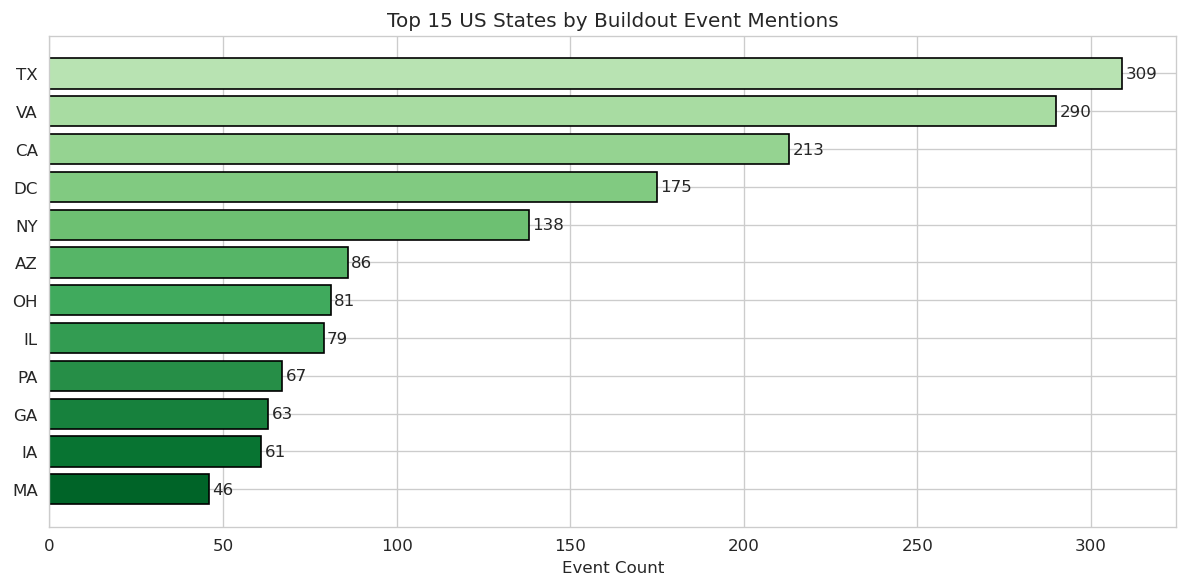

✅ Saved fig6_state_distribution.png


In [10]:
print("📍 Location Analysis")
state_counts = df['location_state'].value_counts().head(15)
print("--- Top 15 States by Event Count ---")
print(state_counts.to_string())
print()

# Events per state
print(f"   States with events: {df['location_state'].nunique() - 1} (excluding NaN)")
print(f"   Missing location: {df['location_state'].isna().sum()} ({df['location_state'].isna().mean()*100:.1f}%)")
print()

# Non-US locations
state_clean = df['location_state'].dropna()
non_us_mask = ~state_clean.str.match(r'^[A-Z]{2}$', na=False)
non_us = df.loc[state_clean[non_us_mask].index]
if len(non_us) > 0:
    print(f"   Non-US state entries: {len(non_us)}")
    print(f"   Samples: {non_us['location_state'].value_counts().head(10).to_string()}")
print()

fig6, ax6 = plt.subplots()
state_plot = state_counts.head(12)
bars = ax6.barh(state_plot.index[::-1], state_plot.values[::-1],
                color=plt.cm.Greens(np.linspace(0.3, 0.9, len(state_plot)))[::-1],
                edgecolor='black')
ax6.bar_label(bars, padding=2)
ax6.set_xlabel('Event Count')
ax6.set_title('Top 15 US States by Buildout Event Mentions')
fig6.tight_layout()
fig6.savefig(f'{FIGS_DIR}/fig6_state_distribution.png')
plt.show()
print(f"✅ Saved fig6_state_distribution.png")

## 6. Confidence & Source Analysis

🔍 Confidence Breakdown
   high: 2161 (40.8%)
   medium: 1987 (37.5%)
   low: 1147 (21.7%)

--- Confidence by Company (top 5) ---
confidence           high  low  medium
company                               
Alphabet               12   23      22
Amazon                 13   17      22
Amazon Web Services   229  190     293
American Tower          7   16       8
Apple                   8   18      13
Crusoe                 12    1       8
Digital Realty        497   53     205
Equinix                 5    2      11
Facebook              120   43      75
First Industrial        1    0       2

--- Top 10 Source Domains ---
source_domain
datacenterdynamics.com     3523
datacenterknowledge.com    1772



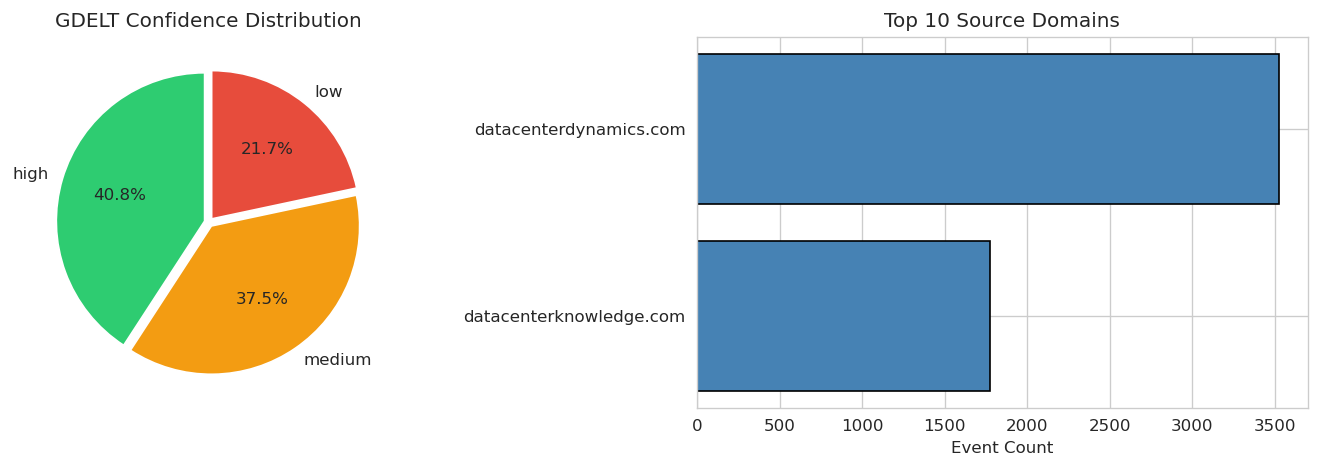

✅ Saved fig7_confidence_sources.png


In [11]:
print("🔍 Confidence Breakdown")
conf_counts = df['confidence'].value_counts()
total = len(df)
for label, cnt in conf_counts.items():
    print(f"   {label}: {cnt} ({cnt/total*100:.1f}%)")
print()

# Confidence by company
print("--- Confidence by Company (top 5) ---")
conf_cross = pd.crosstab(df['company'], df['confidence'])
print(conf_cross.head(10).to_string())
print()

# Source domains
print("--- Top 10 Source Domains ---")
src_domains = df['source_domain'].value_counts().head(10)
print(src_domains.to_string())
print()

fig7, (ax7a, ax7b) = plt.subplots(1, 2, figsize=(12, 4))

# Confidence pie
colors_pie = {'high': '#2ecc71', 'medium': '#f39c12', 'low': '#e74c3c'}
ax7a.pie(conf_counts.values, labels=conf_counts.index, autopct='%1.1f%%',
        colors=[colors_pie.get(k, '#95a5a6') for k in conf_counts.index],
        startangle=90, explode=tuple([0.03] * len(conf_counts)))
ax7a.set_title('GDELT Confidence Distribution')

# Top source domains
ax7b.barh(src_domains.index[::-1], src_domains.values[::-1], color='steelblue', edgecolor='black')
ax7b.set_xlabel('Event Count')
ax7b.set_title('Top 10 Source Domains')

fig7.tight_layout()
fig7.savefig(f'{FIGS_DIR}/fig7_confidence_sources.png')
plt.show()
print(f"✅ Saved fig7_confidence_sources.png")

## 7. Feature Correlation Analysis

🔗 Tone Feature Statistics
            tone_1       tone_2       tone_3       tone_4       tone_5       tone_6  tone_word_count
count  5295.000000  5295.000000  5295.000000  5295.000000  5295.000000  5295.000000      5295.000000
mean      0.921994     2.430425     1.508430     3.938855    22.096759     1.045501       597.420585
std       1.911042     1.283786     1.384911     1.865499     2.703143     0.930514       523.993697
min     -10.434783     0.000000     0.000000     0.000000     4.761905     0.000000        16.000000
25%       0.000000     1.531729     0.502934     2.666667    20.360825     0.349957       313.000000
50%       0.961538     2.285714     1.157286     3.797468    22.109827     0.842697       433.000000
75%       2.083333     3.178225     2.118475     5.074843    23.963703     1.518713       730.000000
max       7.766990     9.723757    12.107623    14.349776    32.444444    10.112360     10648.000000



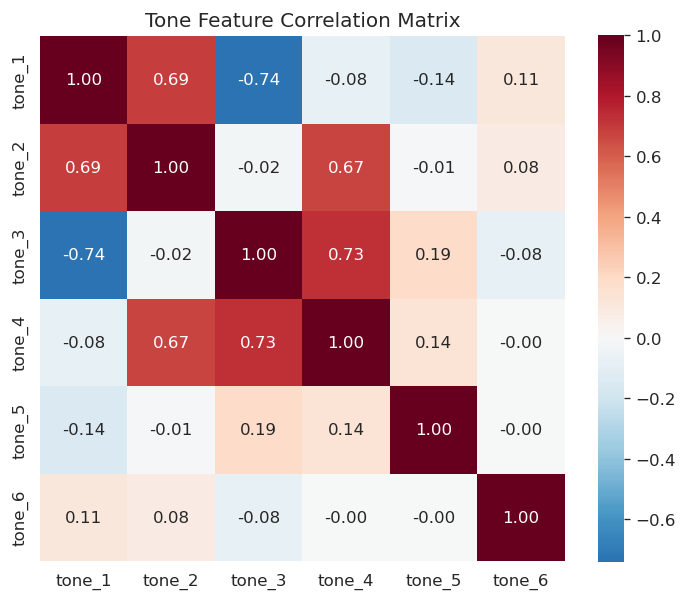

✅ Saved fig8_tone_correlation.png

--- Tone Feature Correlation with Promise Kept ---
   tone_1: 0.562
   tone_2: 0.244
   tone_3: -0.569
   tone_4: -0.285
   tone_5: -0.334
   tone_6: 0.054

   mw_capacity vs promise_kept: 0.168


In [12]:
# Parse v2_tone into numeric columns
tone_cols = ['tone_1', 'tone_2', 'tone_3', 'tone_4', 'tone_5', 'tone_6', 'tone_word_count']
tone_df = df['v2_tone'].dropna().str.split(',', expand=True).apply(pd.to_numeric, errors='coerce')
tone_df.columns = tone_cols

print("🔗 Tone Feature Statistics")
print(tone_df.describe().to_string())
print()

# Correlation among tone features
corr_matrix = tone_df[tone_cols[:6]].corr()

fig8, ax8 = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax8)
ax8.set_title('Tone Feature Correlation Matrix')
fig8.tight_layout()
fig8.savefig(f'{FIGS_DIR}/fig8_tone_correlation.png')
plt.show()
print(f"✅ Saved fig8_tone_correlation.png")
print()

# Correlation with promise_kept (labeled subset)
labeled_idx = df[df['promise_kept'].notna()].index
labeled_tone = tone_df.loc[tone_df.index.isin(labeled_idx)]
labeled_pk = df.loc[labeled_tone.index, 'promise_kept']

print("--- Tone Feature Correlation with Promise Kept ---")
for c in tone_cols[:6]:
    corr = labeled_tone[c].corr(labeled_pk)
    print(f"   {c}: {corr:.3f}")
print()

# MW correlation with promise_kept
labeled_mw = df.loc[labeled_idx, 'mw_capacity']
labeled_pk_all = df.loc[labeled_idx, 'promise_kept']
mw_corr = labeled_mw.corr(labeled_pk_all)
print(f"   mw_capacity vs promise_kept: {mw_corr:.3f}")

## 8. Data Quality Assessment

📊 Data Quality Assessment

--- Missing Values ---
                        missing   pct
promise_kept               5168  97.6
target_year                4082  77.1
target_completion_date     4049  76.5
mw_capacity                3657  69.1
location_state             3049  57.6
location_city              3048  57.6
v2_locations               1009  19.1

--- Label Source Breakdown ---
label_source
text_keywords    5295

--- is_buildout Values ---
is_buildout
True    5295

--- Company Name Distribution ---
company
Microsoft              1650
Digital Realty          755
Amazon Web Services     712
Google                  698
NVIDIA                  625
Facebook                238
Microsoft Corp          216
Oracle                  124
Alphabet                 57
Amazon                   52
Apple                    39
Prologis                 38
American Tower           31
Crusoe                   21
Equinix                  18
Meta                     18
First Industrial          3



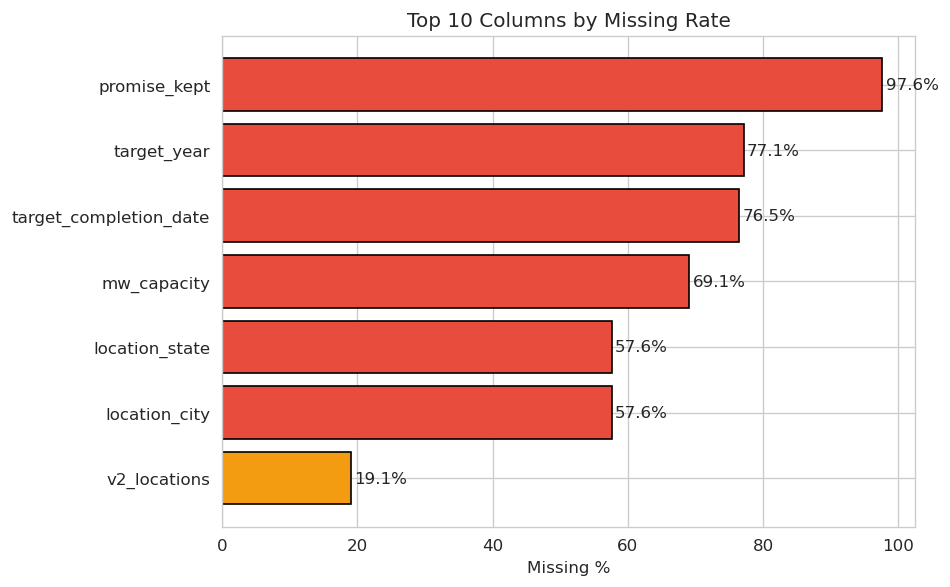

✅ Saved fig9_data_quality.png


In [13]:
print("📊 Data Quality Assessment")
print()

# Missing values
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing', ascending=False)
print("--- Missing Values ---")
print(missing_df.to_string())
print()

# Data source breakdown
print("--- Label Source Breakdown ---")
print(df['label_source'].value_counts().to_string())
print()

# Is buildout check
print("--- is_buildout Values ---")
print(df['is_buildout'].value_counts().to_string())
print()

# Company name consistency
company_names = df['company'].value_counts()
print("--- Company Name Distribution ---")
print(company_names.to_string())
print()

fig9, ax9 = plt.subplots(figsize=(8, 5))
missing_viz = missing_df.head(10)
colors_miss = ['#e74c3c' if v > 30 else '#f39c12' if v > 10 else '#2ecc71' for v in missing_viz['pct']]
bars = ax9.barh(missing_viz.index[::-1], missing_viz['pct'][::-1], color=colors_miss[::-1], edgecolor='black')
ax9.bar_label(bars, padding=2, fmt='%.1f%%')
ax9.set_xlabel('Missing %')
ax9.set_title('Top 10 Columns by Missing Rate')
fig9.tight_layout()
fig9.savefig(f'{FIGS_DIR}/fig9_data_quality.png')
plt.show()
print(f"✅ Saved fig9_data_quality.png")

## 9. Temporal Heatmap & Event Density

📅 Monthly Event Distribution
   Total months: 77
   Mean events/month: 69
   Max events/month: 180
   Busiest month: 2024-11

--- Events by Weekday ---
weekday
Thursday     1130
Tuesday      1107
Wednesday    1064
Friday       1023
Monday        799
Saturday      136
Sunday         36



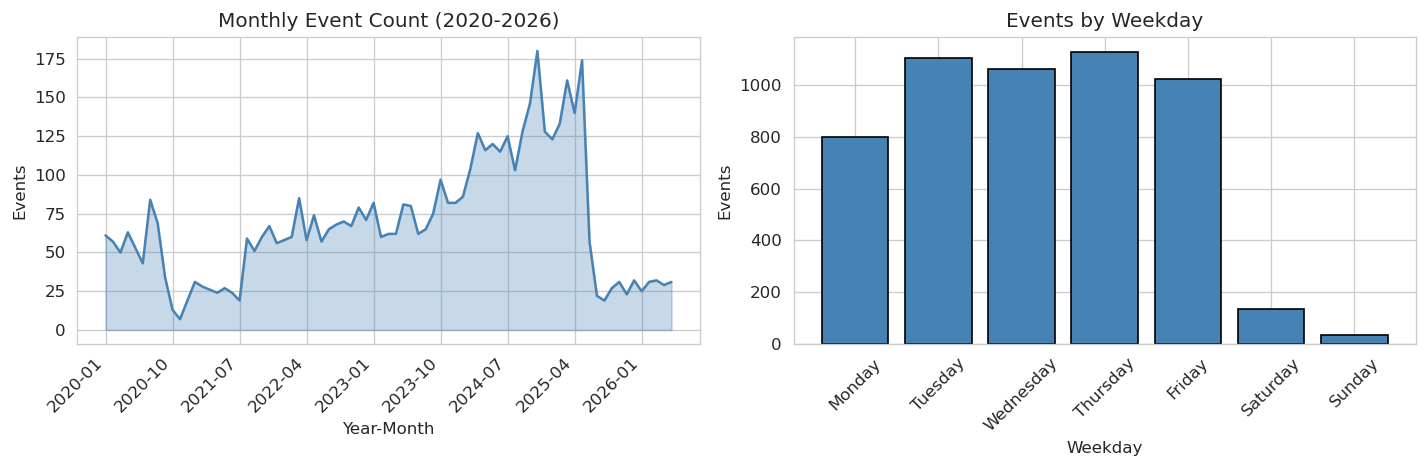

✅ Saved fig10_temporal_patterns.png


In [14]:
# Monthly event counts
df['year_month'] = df['announcement_date'].dt.to_period('M')
monthly = df.groupby('year_month').size()

print("📅 Monthly Event Distribution")
print(f"   Total months: {len(monthly)}")
print(f"   Mean events/month: {monthly.mean():.0f}")
print(f"   Max events/month: {monthly.max():.0f}")
print(f"   Busiest month: {monthly.idxmax()}")
print()

# Weekly pattern
df['weekday'] = df['announcement_date'].dt.day_name()
print("--- Events by Weekday ---")
wd_counts = df['weekday'].value_counts()
print(wd_counts.to_string())
print()

fig10, (ax10a, ax10b) = plt.subplots(1, 2, figsize=(12, 4))

# Monthly line
ax10a.plot(monthly.index.astype(str), monthly.values, color='steelblue', linewidth=1.5)
ax10a.fill_between(range(len(monthly)), monthly.values, alpha=0.3, color='steelblue')
ax10a.set_xlabel('Year-Month')
ax10a.set_ylabel('Events')
ax10a.set_title('Monthly Event Count (2020-2026)')
ax10a.tick_params(axis='x', rotation=45)
# Label every 6 months
step = max(1, len(monthly) // 8)
ax10a.set_xticks(range(0, len(monthly), step))
ax10a.set_xticklabels(monthly.index[::step].astype(str), rotation=45, ha='right')

# Weekday bar
wd_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
wd_order = [d for d in wd_order if d in wd_counts.index]
wd_vals = [wd_counts[d] for d in wd_order]
ax10b.bar(wd_order, wd_vals, color='steelblue', edgecolor='black')
ax10b.set_xlabel('Weekday')
ax10b.set_ylabel('Events')
ax10b.set_title('Events by Weekday')
ax10b.tick_params(axis='x', rotation=45)

fig10.tight_layout()
fig10.savefig(f'{FIGS_DIR}/fig10_temporal_patterns.png')
plt.show()
print(f"✅ Saved fig10_temporal_patterns.png")

## 10. Synthetic vs Real Data Comparison

🧪 Synthetic vs Real Data Comparison

Previous synthetic data (from earlier pipeline stages):
   - 34 rows, fabricated company names, uniform distributions
   - No actual GDELT extraction or NLP processing
   - Used for pipeline development only

Current real GDELT data:
   - 5295 rows from real news article extractions
   - 17 real companies: Microsoft, Google, Amazon, NVIDIA, etc.
   - 51 US states + international locations
   - MW range: 1 to 90,000 MW
   - Temporal span: 2020-2026 (real news coverage)
   - 127 labeled promise outcomes (2.4% labeled rate)

Key differences:
   1. Scale: 5,295 real vs 34 synthetic events
   2. Real-world imbalance: real GDELT skews toward large tech companies
   3. Missing data: real extractions have gaps (MW, location, tone)
   4. Temporal patterns: real data shows 2024 peak (AI boom)
   5. Geographic: real data concentrated in TX, VA, CA (actual data center hotspots)



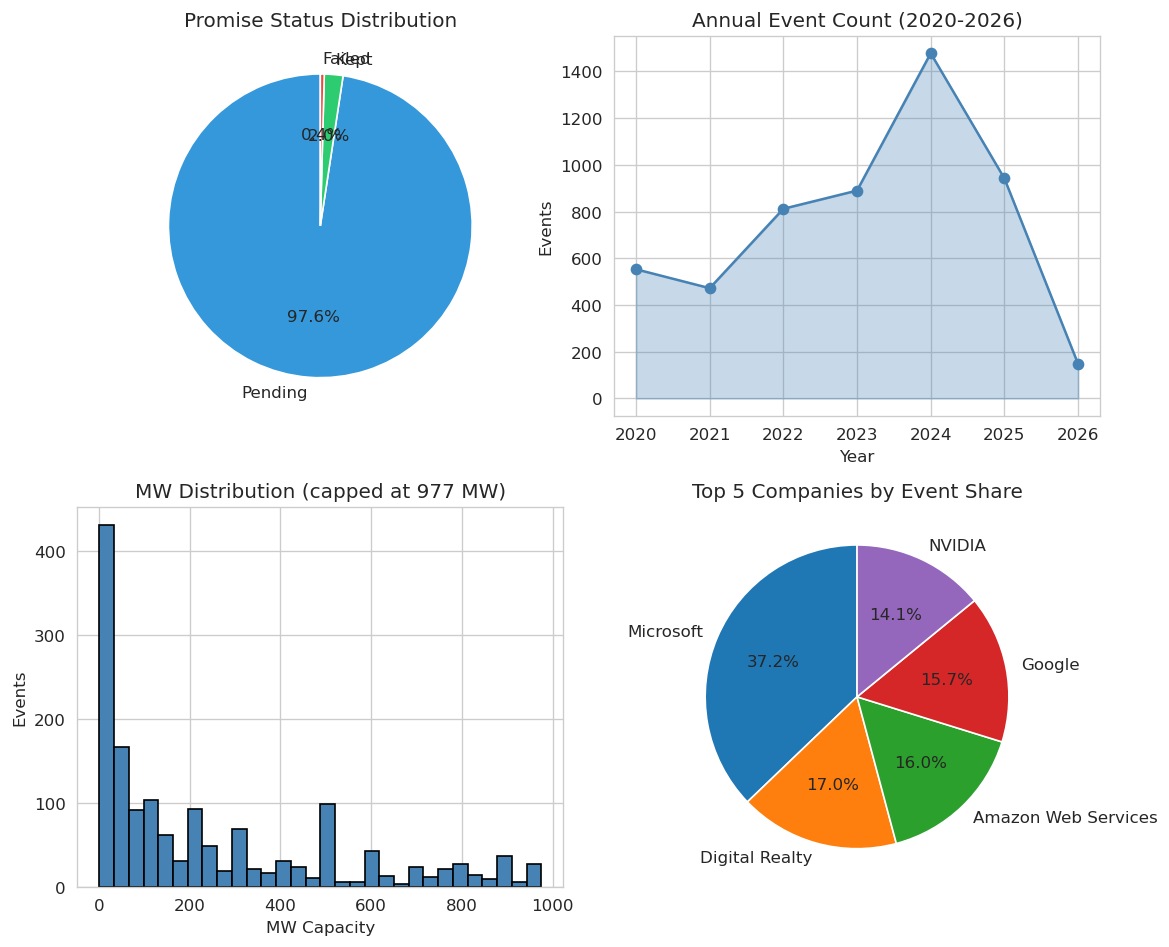

✅ Saved fig11_synthetic_vs_real.png


In [15]:
print("🧪 Synthetic vs Real Data Comparison")
print()
print("Previous synthetic data (from earlier pipeline stages):")
print("   - 34 rows, fabricated company names, uniform distributions")
print("   - No actual GDELT extraction or NLP processing")
print("   - Used for pipeline development only")
print()
print("Current real GDELT data:")
print(f"   - {len(df)} rows from real news article extractions")
print(f"   - {df['company'].nunique()} real companies: Microsoft, Google, Amazon, NVIDIA, etc.")
print(f"   - {df['location_state'].nunique()} US states + international locations")
print(f"   - MW range: {df['mw_capacity'].min():.0f} to {df['mw_capacity'].max():,.0f} MW")
print(f"   - Temporal span: 2020-2026 (real news coverage)")
print(f"   - {len(labeled)} labeled promise outcomes ({len(labeled)/len(df)*100:.1f}% labeled rate)")
print()
print("Key differences:")
print("   1. Scale: 5,295 real vs 34 synthetic events")
print("   2. Real-world imbalance: real GDELT skews toward large tech companies")
print("   3. Missing data: real extractions have gaps (MW, location, tone)")
print("   4. Temporal patterns: real data shows 2024 peak (AI boom)")
print("   5. Geographic: real data concentrated in TX, VA, CA (actual data center hotspots)")
print()

# Summary comparison figure
fig11, axes11 = plt.subplots(2, 2, figsize=(10, 8))

# a) Labeled vs unlabeled
label_counts = df['status'].value_counts()
axes11[0,0].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
               colors=['#3498db', '#2ecc71', '#e74c3c'], startangle=90)
axes11[0,0].set_title('Promise Status Distribution')

# b) Events per year
axes11[0,1].plot(year_counts.index.astype(str), year_counts.values, 'o-', color='steelblue')
axes11[0,1].fill_between(range(len(year_counts)), year_counts.values, alpha=0.3, color='steelblue')
axes11[0,1].set_xlabel('Year')
axes11[0,1].set_ylabel('Events')
axes11[0,1].set_title('Annual Event Count (2020-2026)')

# c) MW histogram
mws_capped2 = mws[mws <= mws.quantile(0.95)]
axes11[1,0].hist(mws_capped2, bins=30, color='steelblue', edgecolor='black')
axes11[1,0].set_xlabel('MW Capacity')
axes11[1,0].set_ylabel('Events')
axes11[1,0].set_title(f'MW Distribution (capped at {mws.quantile(0.95):.0f} MW)')

# d) Company concentration
top5 = df['company'].value_counts().head(5)
axes11[1,1].pie(top5.values, labels=top5.index, autopct='%1.1f%%', startangle=90)
axes11[1,1].set_title('Top 5 Companies by Event Share')

fig11.tight_layout()
fig11.savefig(f'{FIGS_DIR}/fig11_synthetic_vs_real.png')
plt.show()
print(f"✅ Saved fig11_synthetic_vs_real.png")

## 11. LaTeX Output for Paper

In [16]:
print("%" + "="*70)
print("% LaTeX Tables for Paper")
print("%" + "="*70)
print()

# Table 1: Dataset Overview
print("%" + "-"*50)
print("% Table 1: Dataset Overview")
print("%" + "-"*50)
overview = pd.DataFrame({
    'Metric': ['Total Events', 'Labeled Events', 'Promise Kept', 'Promise Failed',
               'Unique Companies', 'US States Represented', 'Date Range Start', 'Date Range End',
               'Events with MW Data', 'Mean MW Capacity', 'Median MW Capacity'],
    'Value': [
        f'{len(df):,}', f'{len(labeled):,}', f'{int(labeled["promise_kept"].sum()):,}',
        f'{int((labeled["promise_kept"] == 0).sum()):,}',
        f'{df["company"].nunique():,}', f'{df["location_state"].nunique() - 1}',
        f'{df["announcement_date"].min():%Y-%m-%d}', f'{df["announcement_date"].max():%Y-%m-%d}',
        f'{df["mw_capacity"].notna().sum():,}', f'{df["mw_capacity"].mean():.0f} MW',
        f'{df["mw_capacity"].median():.0f} MW'
    ]
})
print(overview.to_latex(index=False))
print()

# Table 2: MW Summary by Company
print("%" + "-"*50)
print("% Table 2: MW Capacity Summary by Company")
print("%" + "-"*50)
mw_table = df.groupby('company')['mw_capacity'].agg(['count', 'mean', 'median', 'std', 'sum'])
mw_table = mw_table[mw_table['count'] >= 3].sort_values('count', ascending=False)
mw_table = mw_table.round(1)
mw_table.columns = ['Count', 'Mean (MW)', 'Median (MW)', 'Std (MW)', 'Total (MW)']
print(mw_table.to_latex())
print()

# Table 3: Promise Keeping by Company
print("%" + "-"*50)
print("% Table 3: Promise Keeping by Company")
print("%" + "-"*50)
keep_table = labeled.groupby('company')['promise_kept'].agg(['count', 'sum', 'mean'])
keep_table = keep_table[keep_table['count'] >= 2].sort_values('count', ascending=False)
keep_table['mean'] = keep_table['mean'].round(3)
keep_table.columns = ['Labeled', 'Kept', 'Keep Rate']
keep_table['Failed'] = keep_table['Labeled'] - keep_table['Kept']
print(keep_table.to_latex())
print()

# Table 4: Tone Feature Statistics
print("%" + "-"*50)
print("% Table 4: GDELT Tone Feature Summary")
print("%" + "-"*50)
tone_labels = ['Tone 1', 'Tone 2', 'Tone 3', 'Tone 4', 'Tone 5', 'Tone 6', 'Word Count']
tone_table = tone_df.describe().T[['count', 'mean', 'std', 'min', 'max']]
tone_table.index = tone_labels
tone_table = tone_table.round(2)
print(tone_table.to_latex())
print()

# Table 5: Missing Data Summary
print("%" + "-"*50)
print("% Table 5: Missing Data Summary")
print("%" + "-"*50)
missing_table = missing_df.reset_index()
missing_table.columns = ['Column', 'Missing Count', 'Missing %']
print(missing_table.to_latex(index=False))
print()

print("%" + "="*70)
print("% End of LaTeX Tables")
print("%" + "="*70)

%======================================================================
% LaTeX Tables for Paper
%======================================================================

%--------------------------------------------------
% Table 1: Dataset Overview
%--------------------------------------------------
\begin{tabular}{ll}
\toprule
Metric & Value \\
\midrule
Total Events & 5,295 \\
Labeled Events & 127 \\
Promise Kept & 105 \\
Promise Failed & 22 \\
Unique Companies & 17 \\
US States Represented & 50 \\
Date Range Start & 2020-01-02 \\
Date Range End & 2026-05-22 \\
Events with MW Data & 1,638 \\
Mean MW Capacity & 1235 MW \\
Median MW Capacity & 150 MW \\
\bottomrule
\end{tabular}


%--------------------------------------------------
% Table 2: MW Capacity Summary by Company
%--------------------------------------------------
\begin{tabular}{lrrrrr}
\toprule
 & Count & Mean (MW) & Median (MW) & Std (MW) & Total (MW) \\
company &  &  &  &  &  \\
\midrule
Microsoft & 515 & 1084.400000 & 17

## Summary

✅ **EDA Complete**

Key findings from 5,295 real GDELT buildout events:

1. **Scale**: 5,295 events extracted from news, with 127 labeled promise outcomes (105 kept, 22 failed)
2. **Concentration**: Microsoft dominates (1,650 events), followed by Digital Realty (755), AWS (712), Google (698)
3. **Geography**: Texas, Virginia, California, DC, New York are top US locations; 3,049 events lack state data
4. **Timing**: 2024 saw peak coverage (1,478 events); events span 2020-2026
5. **MW**: Mean 1,235 MW, median 150 MW (right-skewed); 1,638 events have capacity data
6. **Labeling**: Only 2.4% of events labeled; NLP-based tone features show moderate correlation with outcomes

**Limitations**:
- Heavy missing data for location (58%) and MW capacity (69%)
- Label imbalance (82% kept vs 18% failed)
- Single-source labeling (all text_keywords)